# Notebook métricas de evaluación con RR Lyrae

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)


In [1]:
import pandas as pd
import numpy as np

import sklearn.tree
from sklearn.tree import DecisionTreeClassifier #modelo
from sklearn.tree import plot_tree #visualizacion arbol
from sklearn.model_selection import train_test_split
from sklearn import metrics #métricas
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate #validación cruzada
from sklearn.model_selection import KFold, StratifiedKFold #validación cruzada

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #matriz de confusión


from scipy import stats

In [2]:
from io import StringIO
from IPython.display import Image
#import pydotplus
from sklearn.tree import export_graphviz

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size': 8}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=8)
matplotlib.rc('ytick', labelsize=8)
matplotlib.rcParams['figure.dpi'] = 300

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [4]:
#cargamos los datos como arreglos numpy
features= np.loadtxt("RRLyrae_features_small.txt", delimiter=',')
targets= np.loadtxt("RRLyrae_labels_small.txt", delimiter=',')


In [5]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)

df.head()

,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0


### Preguntas
1. ¿Este es un problema de clasificación o regresión?
2. ¿Es un problema binario o multiclase?
3. ¿Qué representa la variable objetivo?
4. ¿Las clases están balanceadas o desbalanceadas?
5. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?

#### Respuestas
1. clasificacion
2. binario
3. si una estrella es RRLyrae o no
4. Desbalanceadas
5. porque si elegimos mal que metrica usar esto nos podria dar la falsa sensacion de que niuestro modelo es perfecto cuando no lo es

#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

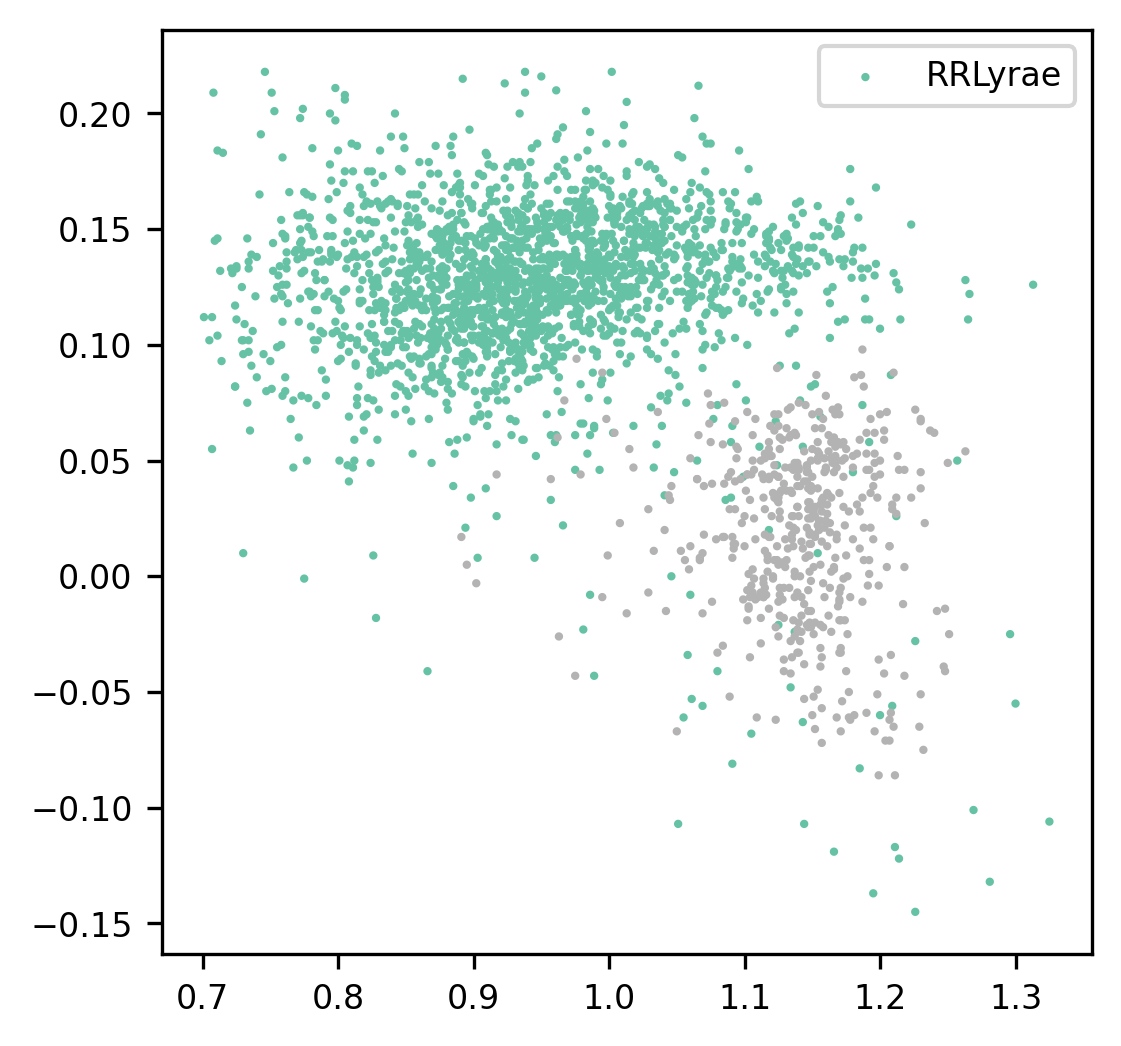

In [6]:
#complete la celda
plt.figure(figsize=(4,4))

sc=plt.scatter(df["g-r"],df["r-i"],s=1,c=df["RR_Lyrae"],cmap="Set2",label="RRLyrae")
plt.legend()
plt.show()

### Pregunta
1. ¿Se observan regiones donde las clases parecen separarse?
2. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?

#### Respuesta
1. Si se observan regiones claras de un tipo y de otro
2. si esperaria que un arbol de decision funcione bien

#### Separe los datos en entrenamiento y prueba

In [7]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]

In [8]:
#complete la celda
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?
2. ¿Por qué eso podría afectar la evaluación del modelo?
3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?

#### Respuestas 
1. No es buena idea porque estamos con datos desbalanceados, y corremos el riesgo de que nuestro set de entrenamiento no sea representativo
2. si faltan datos importantes en el set de entrenamiento el modelo no tendra suficientes datos para aperender los patrones para detectar RRLyrae y sera inutil
3. No elegir aleatorimente los set de entrenamiento y prueba, es mejor usar una funcion como train_set_split pero estratificada para que antenga las proporciones


#### Ahora entrenaremos un árbol de decisión (modelo base)

In [9]:
model_tree = DecisionTreeClassifier(random_state=42)

#entrene el modelo y genere las predicciones



In [10]:
model_tree.fit(X_train, y_train)
y_pred = model_tree.predict(X_test)
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       600
           1       0.95      0.94      0.94       145

    accuracy                           0.98       745
   macro avg       0.97      0.96      0.97       745
weighted avg       0.98      0.98      0.98       745



#### Visualicemos el árbol

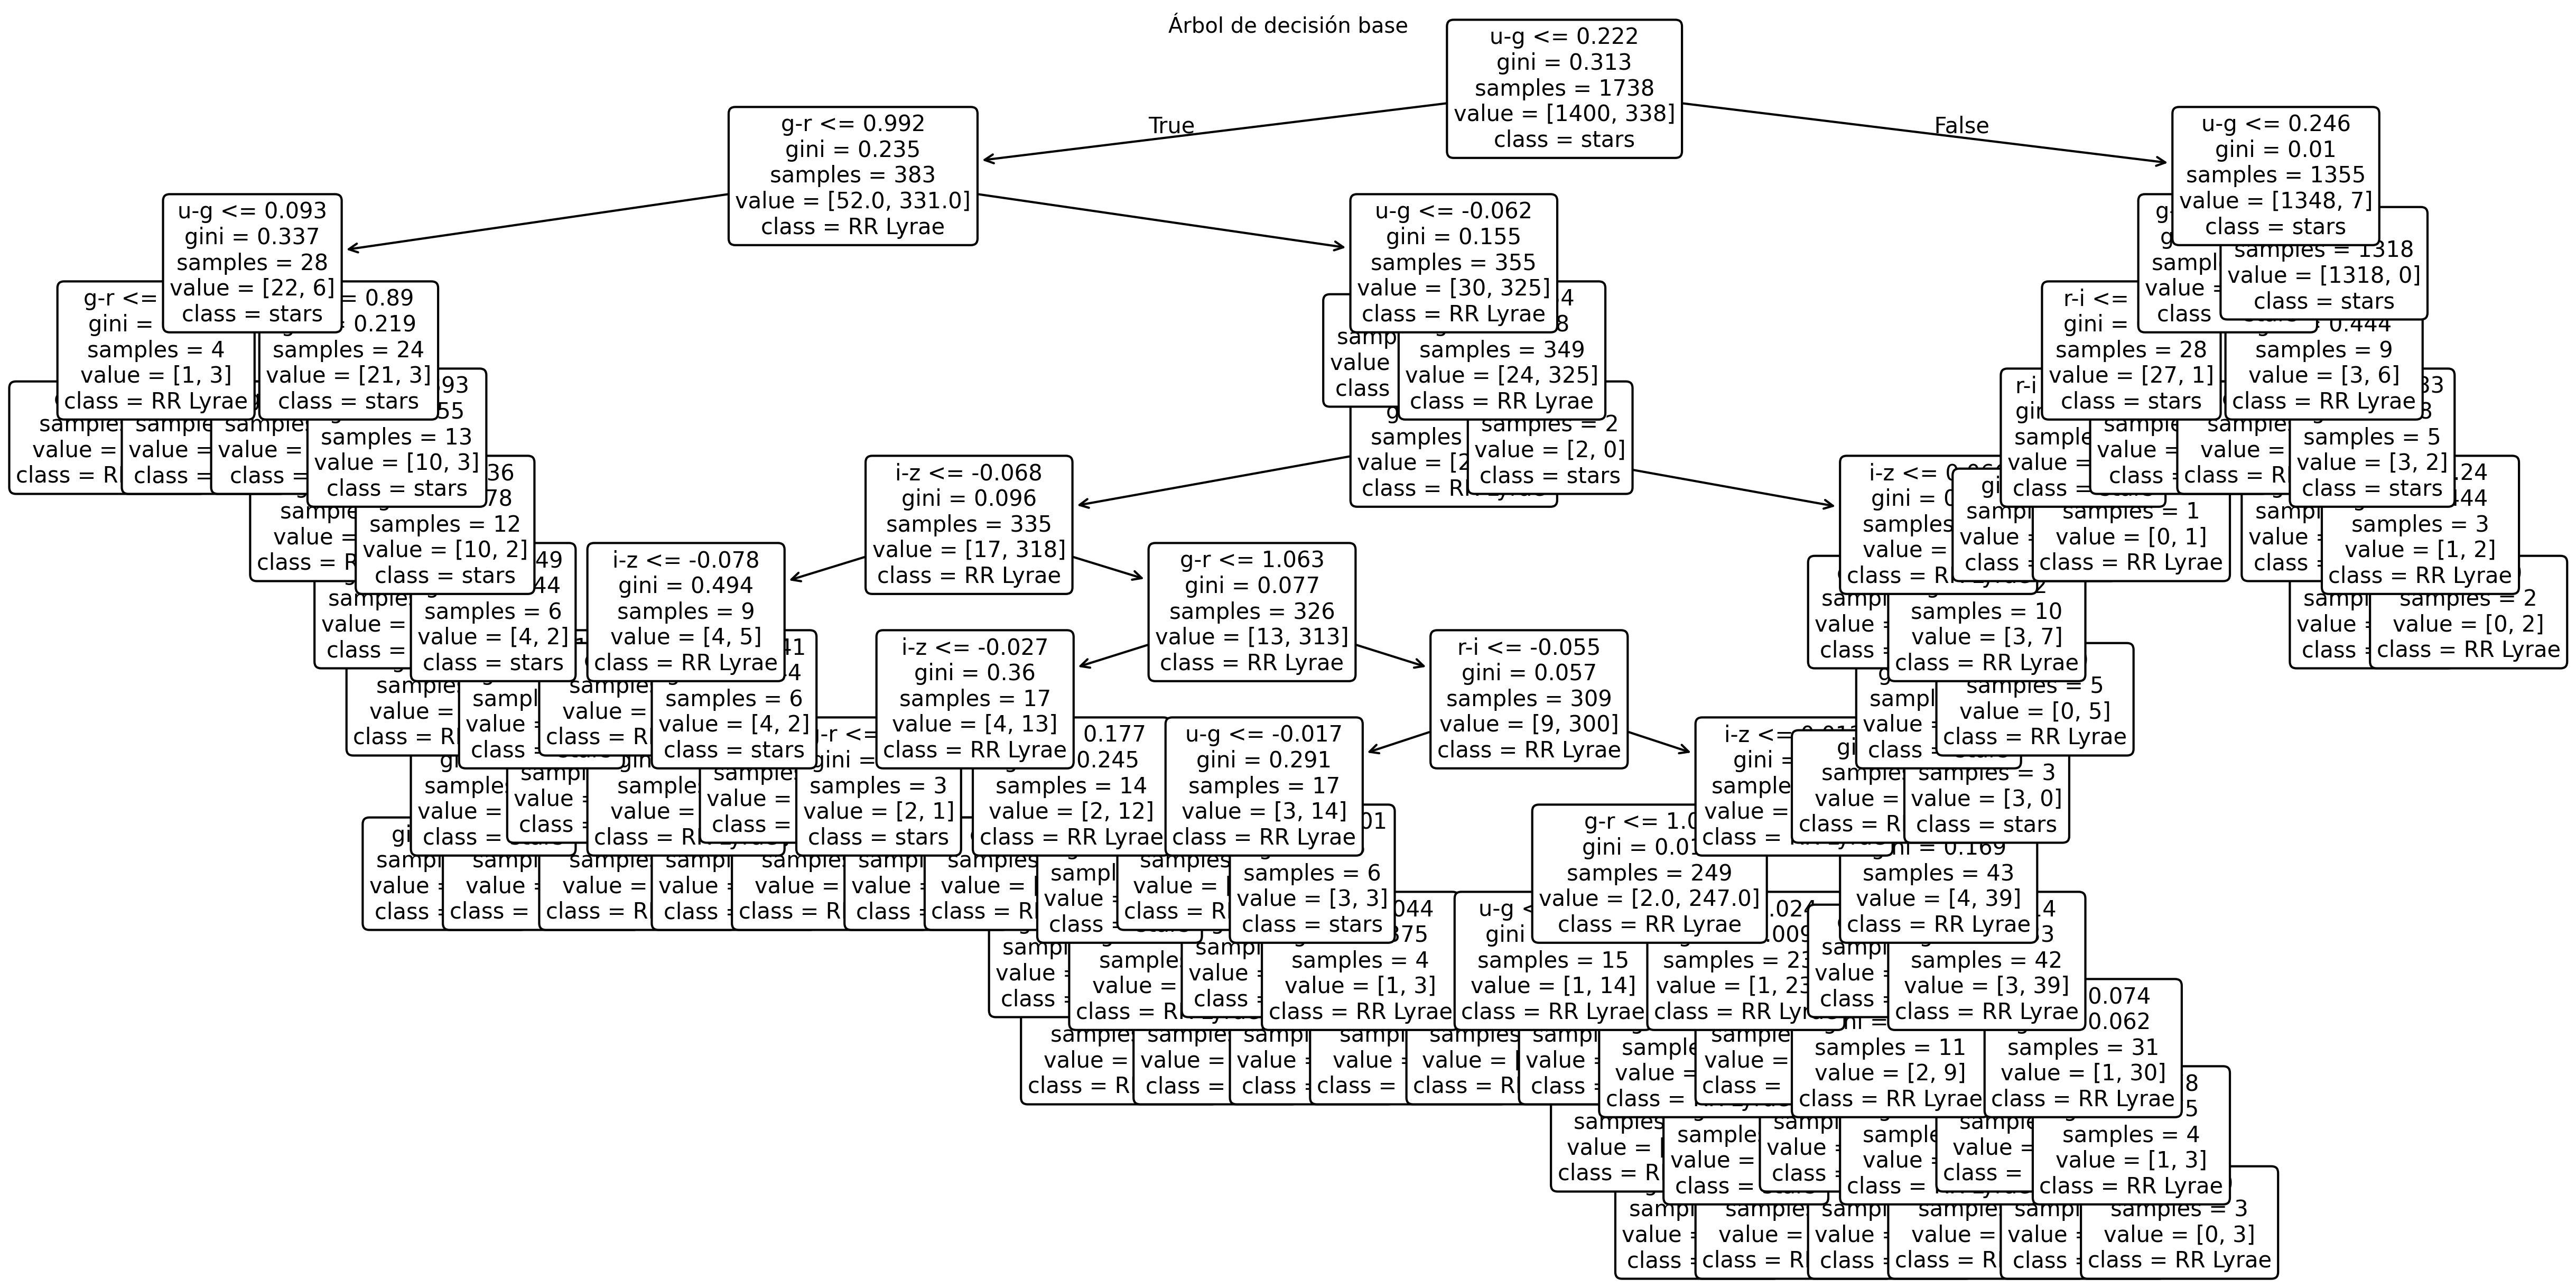

In [11]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

### Preguntas

Observe la estructura del árbol y responda brevemente:

1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones.
2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este?

### Respuestas
1. Claramente parece un arbol muy complejo, tiene una profundidad alta
2. Podria sobreajustar los datos

#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [12]:
print(metrics.accuracy_score(y_train, model_tree.predict(X_train))) #train score

print(metrics.accuracy_score(y_test, model_tree.predict(X_test))) #test score

1.0
0.978523489932886


#### Otras métricas

In [13]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

Precision: 0.951048951048951
Recall   : 0.9379310344827586
F1-score : 0.9444444444444444


In [14]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[593,   7],
       [  9, 136]], dtype=int64)

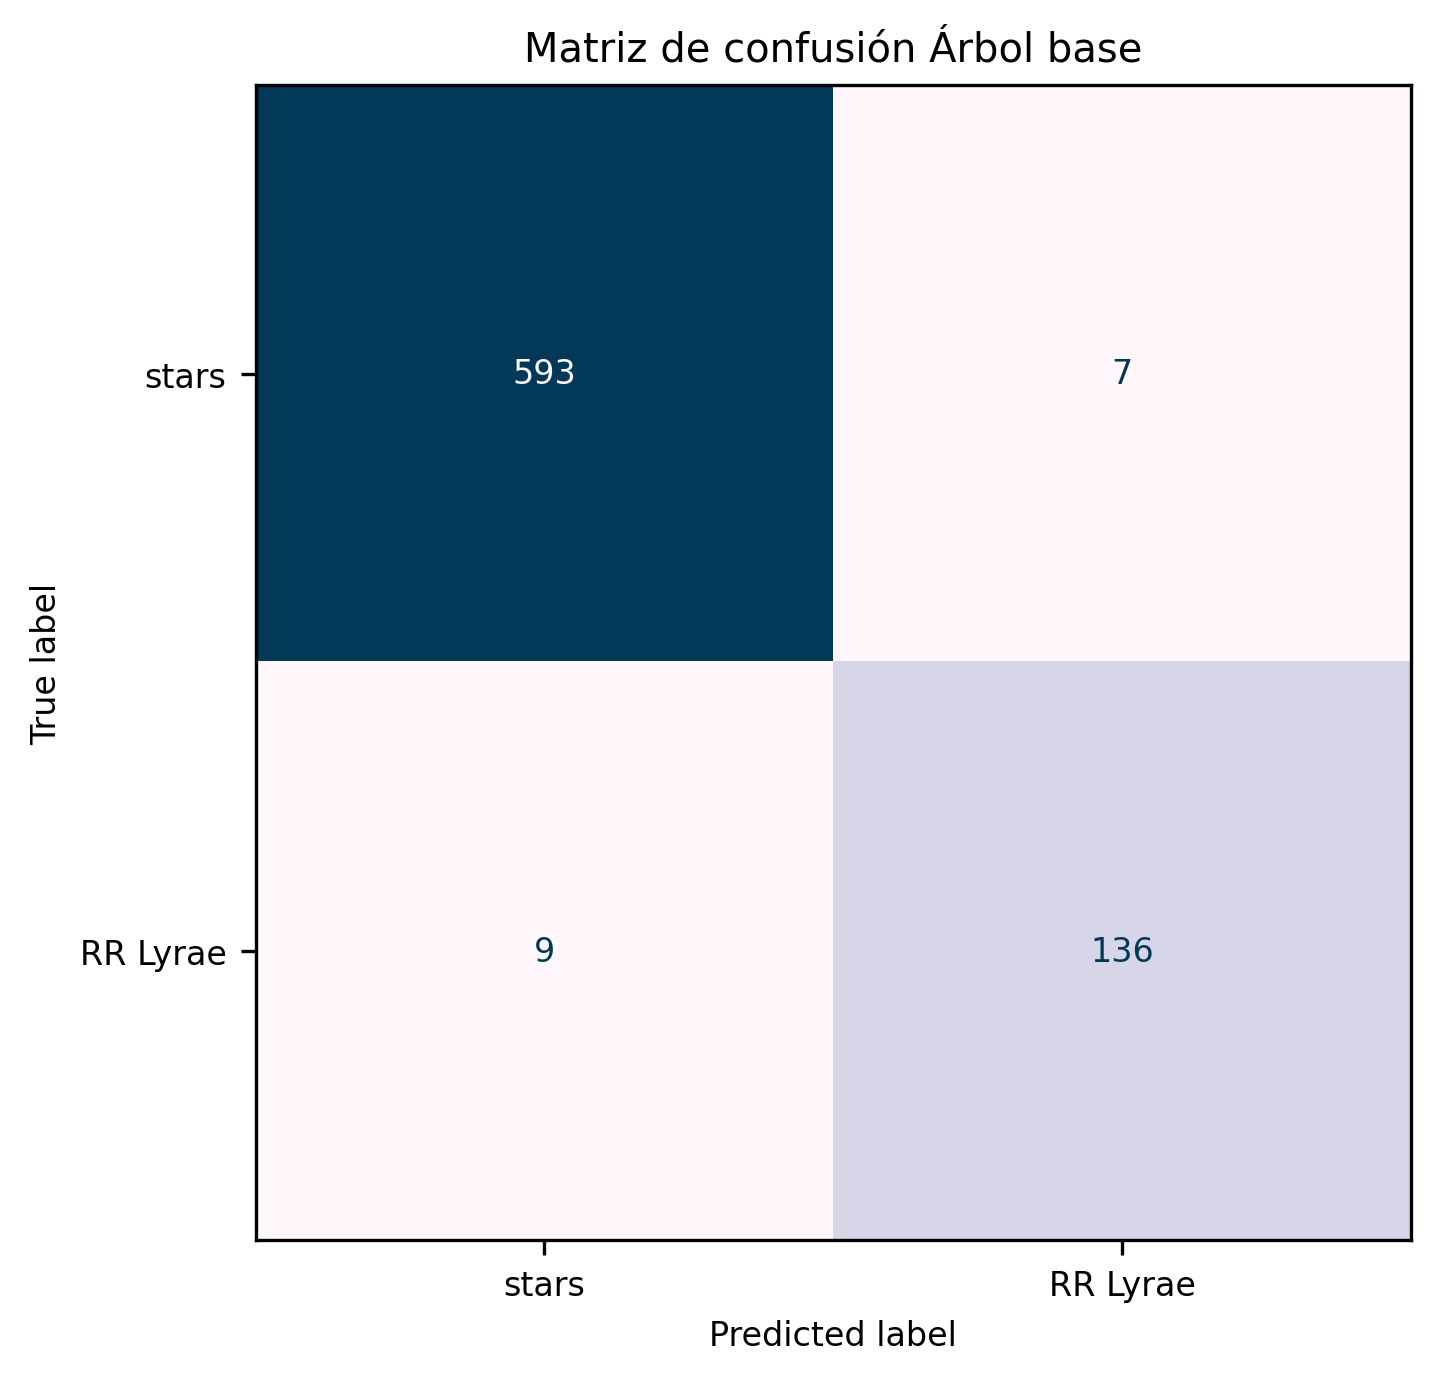

In [15]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP)
   - verdaderos negativos (TN)
   - falsos positivos (FP)
   - falsos negativos (FN)

   Respuestas: 
   TP= 136
   TN= 593
   FP= 9
   FN= 7

2. Calcule las métricas "a mano"



In [16]:
precision=136/ 136+9
print(precision)

10.0


### Preguntas
1. Explique con sus palabras qué significa, en este problema:
   - un falso positivo
   - un falso negativo

2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más?

3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más?

### Respuestas
1. Aqui un falso positivo es cuando el modelo predice una RRLyrae pero en verdad no lo es. Y un falso negativo seria una RRLyrae que el modelo reconocio erroneamente como una estrella comun
2. Si no quisiera saltarme ni una RRLyrae el error mas preocupante serian los falsos negativos
3. me preocuparia los falso positivo  

#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [17]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.

cv1 = KFold(n_splits = 5)

#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)

cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)

# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.

cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [18]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x000002942A5B5CF0>

In [19]:
for train, test in cv1.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [20]:
for train, test in cv2.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [21]:
for train, test in cv3.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario.

In [22]:
scores1 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv1, scoring = 'accuracy')

scores2 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv2, scoring = 'accuracy')

scores3 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv3, scoring = 'accuracy')

In [23]:
scores3

{'fit_time': array([0.00159526, 0.00816584, 0.00707102, 0.00508571, 0.00501299]),
 'score_time': array([0.        , 0.        , 0.00145626, 0.00103188, 0.00216174]),
 'test_score': array([0.98390342, 0.96579477, 0.96780684, 0.97379032, 0.96169355])}

Solo nos interesa el 'test_score'

#### Calculamos el promedio y $\sigma$

In [24]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.785 0.380


In [25]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.965 0.013


In [26]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.971 0.008


La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable, con una desviación estándar extremadamente alta. Esto ocurre porque los datos están ordenados por clase, de modo que algunos folds no representan bien el problema completo.

Al activar el barajado (`cv2`), el rendimiento mejora drásticamente y la dispersión disminuye. Sin embargo, el método que resulta más apropiado para este problema es `StratifiedKFold` (`cv3`), ya que además de mezclar los datos, conserva aproximadamente la proporción de clases en cada fold.

En problemas de clasificación desbalanceada, esta última estrategia suele ser la más recomendable.

In [27]:
scores1 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv3, scoring = 'recall')

c:\Users\cris4\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cris4\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cris4\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [28]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.903 0.016
0.925 0.019


### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.¶

In [29]:
scores1 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv1, scoring = 'recall', \
                         return_train_score = True)

scores2 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv2, scoring = 'recall', \
                         return_train_score = True)

scores3 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv3, scoring = 'recall',
                         return_train_score = True)

c:\Users\cris4\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cris4\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cris4\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [30]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.915 1.000
0.923 1.000


### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [31]:
y_cv3 = cross_val_predict(model_tree, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [32]:
metrics.confusion_matrix(targets,y_cv3)

array([[1961,   39],
       [  33,  450]], dtype=int64)

### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [33]:
y_cv2 = cross_val_predict(model_tree, X,y, cv = cv2)

In [34]:
np.sum(y_cv3-y_cv2)

4

In [35]:
np.sum(y_cv2)

485

In [36]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

52

In [37]:
metrics.confusion_matrix(targets,y_cv2)

array([[1956,   44],
       [  42,  441]], dtype=int64)

In [38]:
metrics.confusion_matrix(targets,y_cv3)

array([[1961,   39],
       [  33,  450]], dtype=int64)

In [39]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

In [40]:
model = DecisionTreeClassifier(random_state = 5)

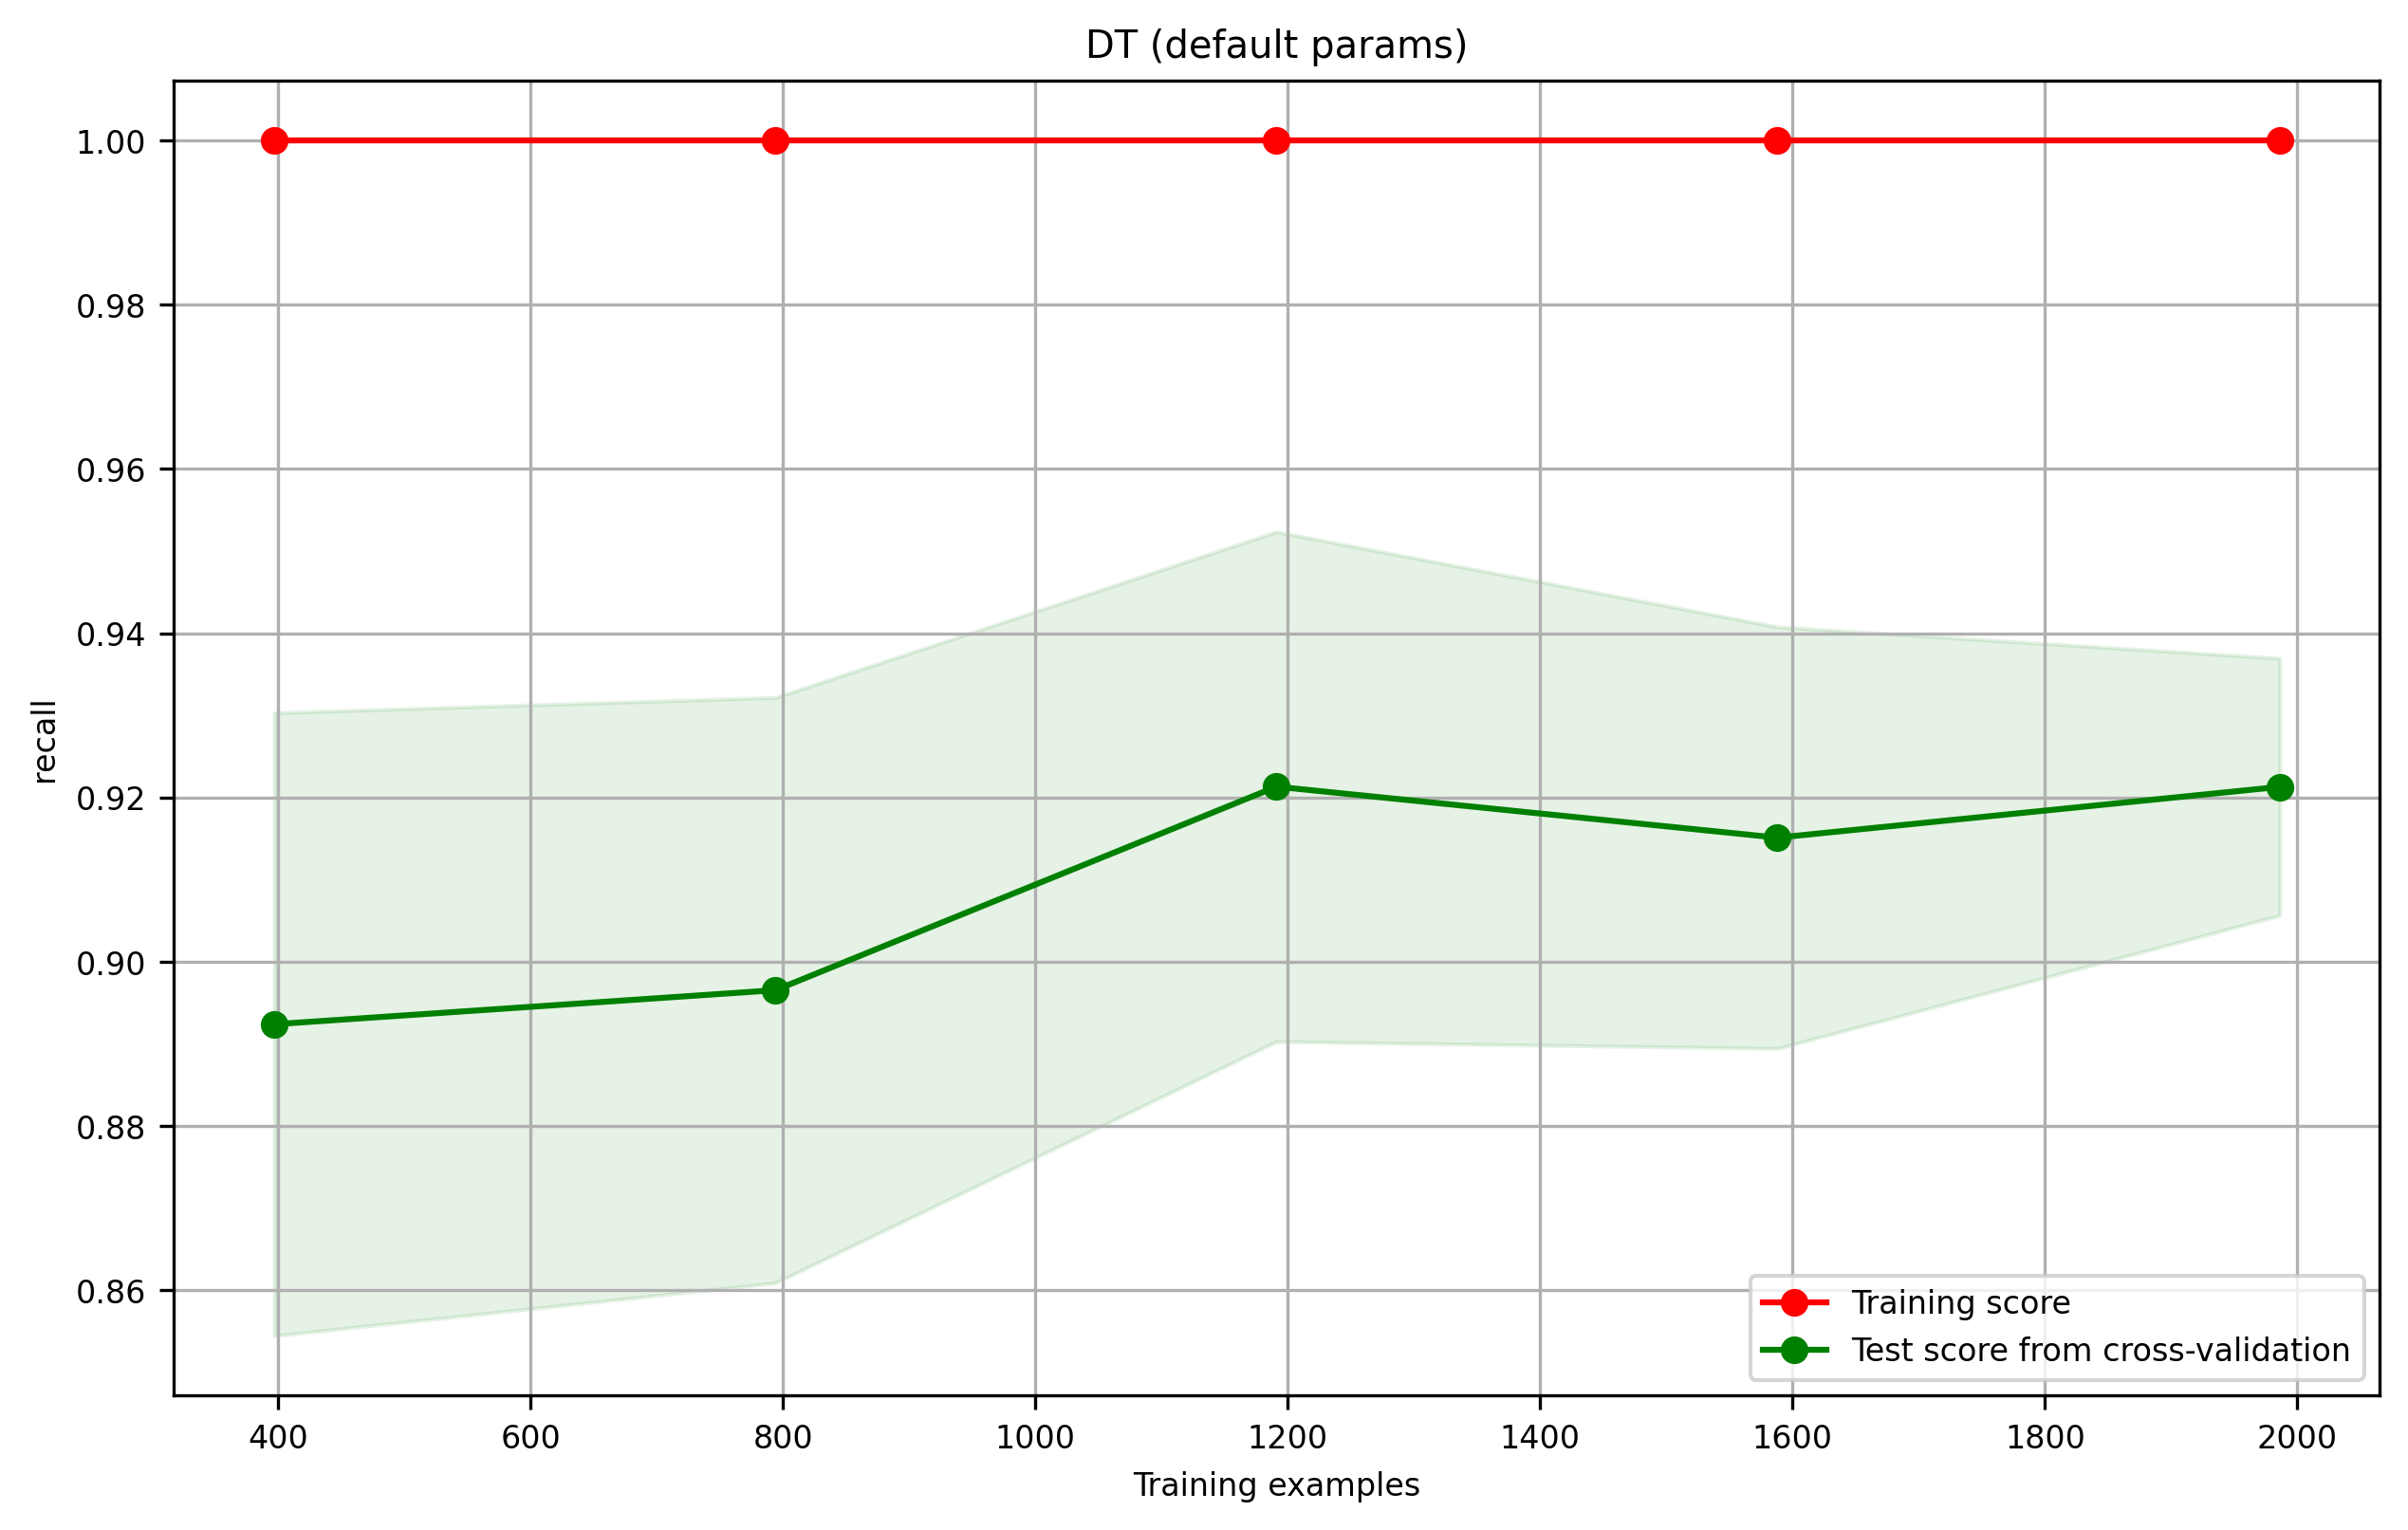

In [41]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

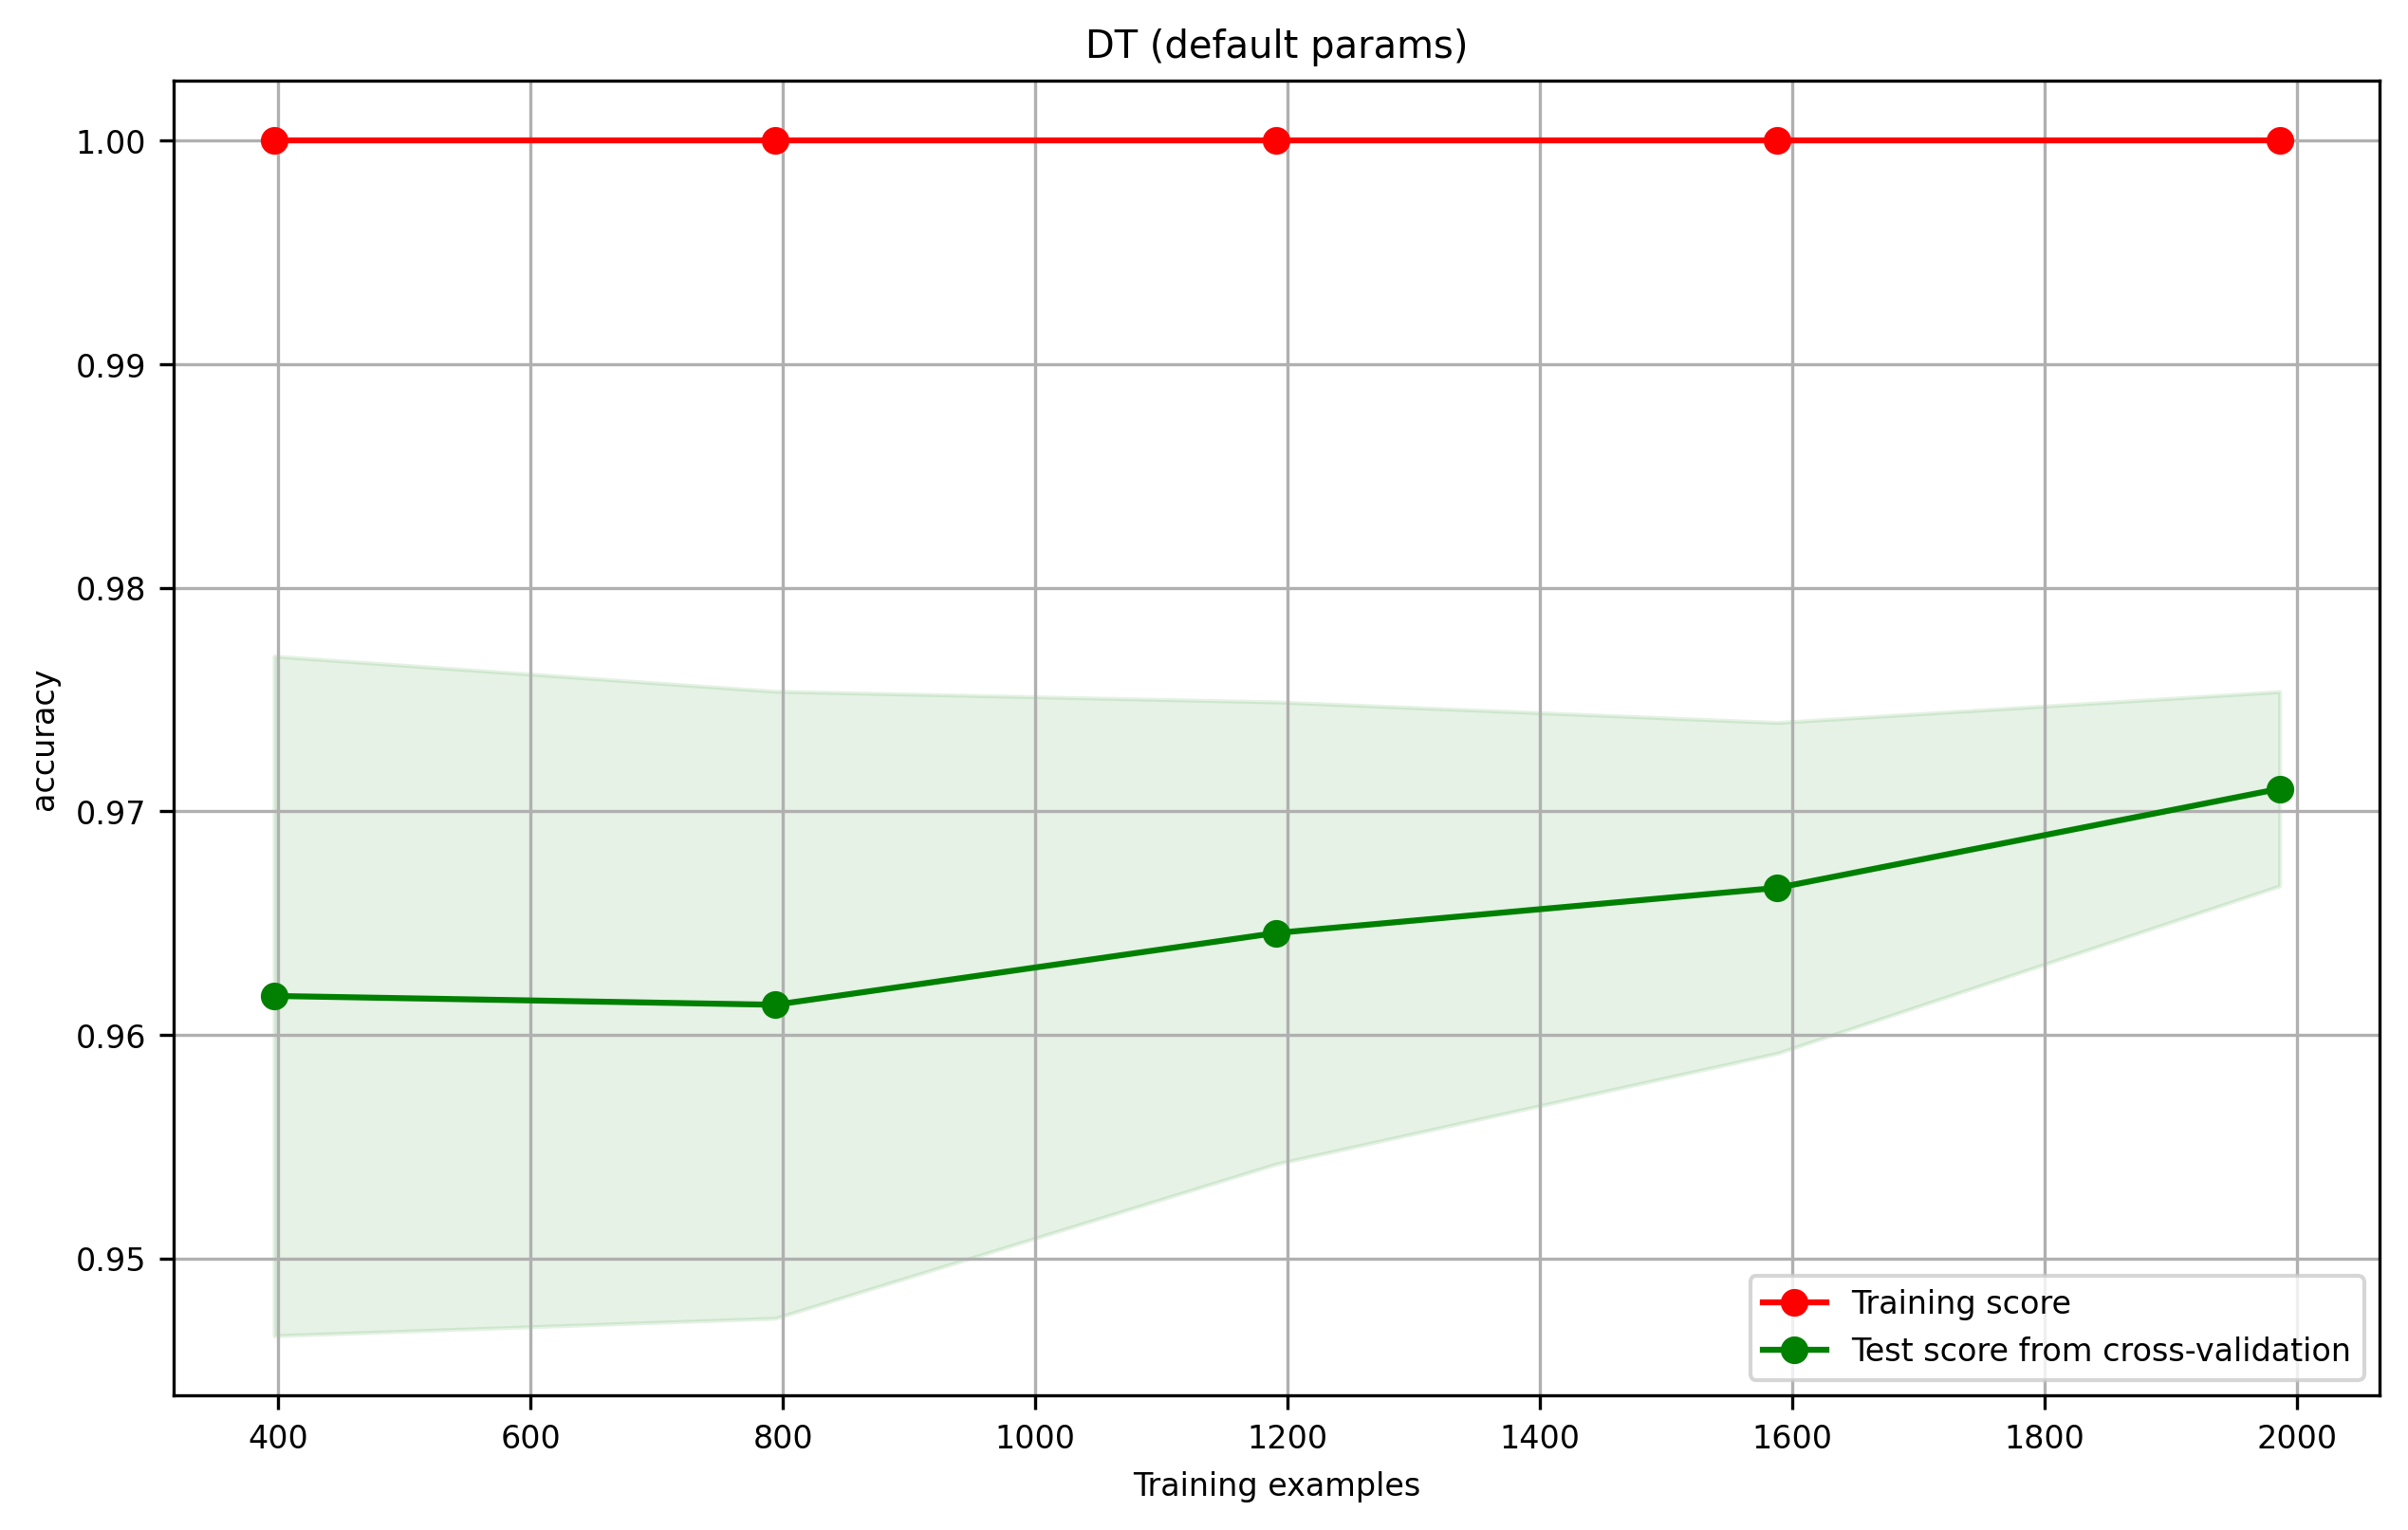

In [42]:
plot_learning_curve(model_tree, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### **Preguntas**

Responda brevemente:

1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?
2. ¿El rendimiento de validación mejora al agregar más ejemplos?
3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique.
4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas.

### RESPUESTAS:
1. Si hay una brecha, esto sugiere que el modelo se esta aprendiendo los datos de entrenamiento de memoria pero no logra aplicar el conocimiento a datos nuevos
2. agregar datos nuevos no soluciona el problema del sobreajuste
3. Diria que hay una alta varianza, el modelo al ser tan complejo se sobreajusta y no predice bien datos nuevos
4. Si no le damos ni un hiperparametro el modelo crece y crece hasta que se aprende los datos de entrenamiento perfectamente pero esto no necesariamente significa que predice bien datos nuevos, 


### Desafío: ¿un árbol más simple generaliza mejor?

Entrene ahora un segundo árbol, más restringido que el árbol base. Por ejemplo, puede probar con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego compare su rendimiento con el árbol base usando:

- accuracy
- precision
- recall
- F1-score



In [43]:
model_tree2=DecisionTreeClassifier(max_depth=3,min_samples_leaf=10) #creo mi modelo y lo entreno
model_tree2.fit(X_train,y_train)
y_pred2= model_tree2.predict(X_test) #genero las predicciones



In [44]:
#metricas de mi modelo 2
print(metrics.accuracy_score(y_train, model_tree2.predict(X_train))) #train score

print(metrics.accuracy_score(y_test, model_tree2.predict(X_test))) #test score



0.976409666283084
0.974496644295302


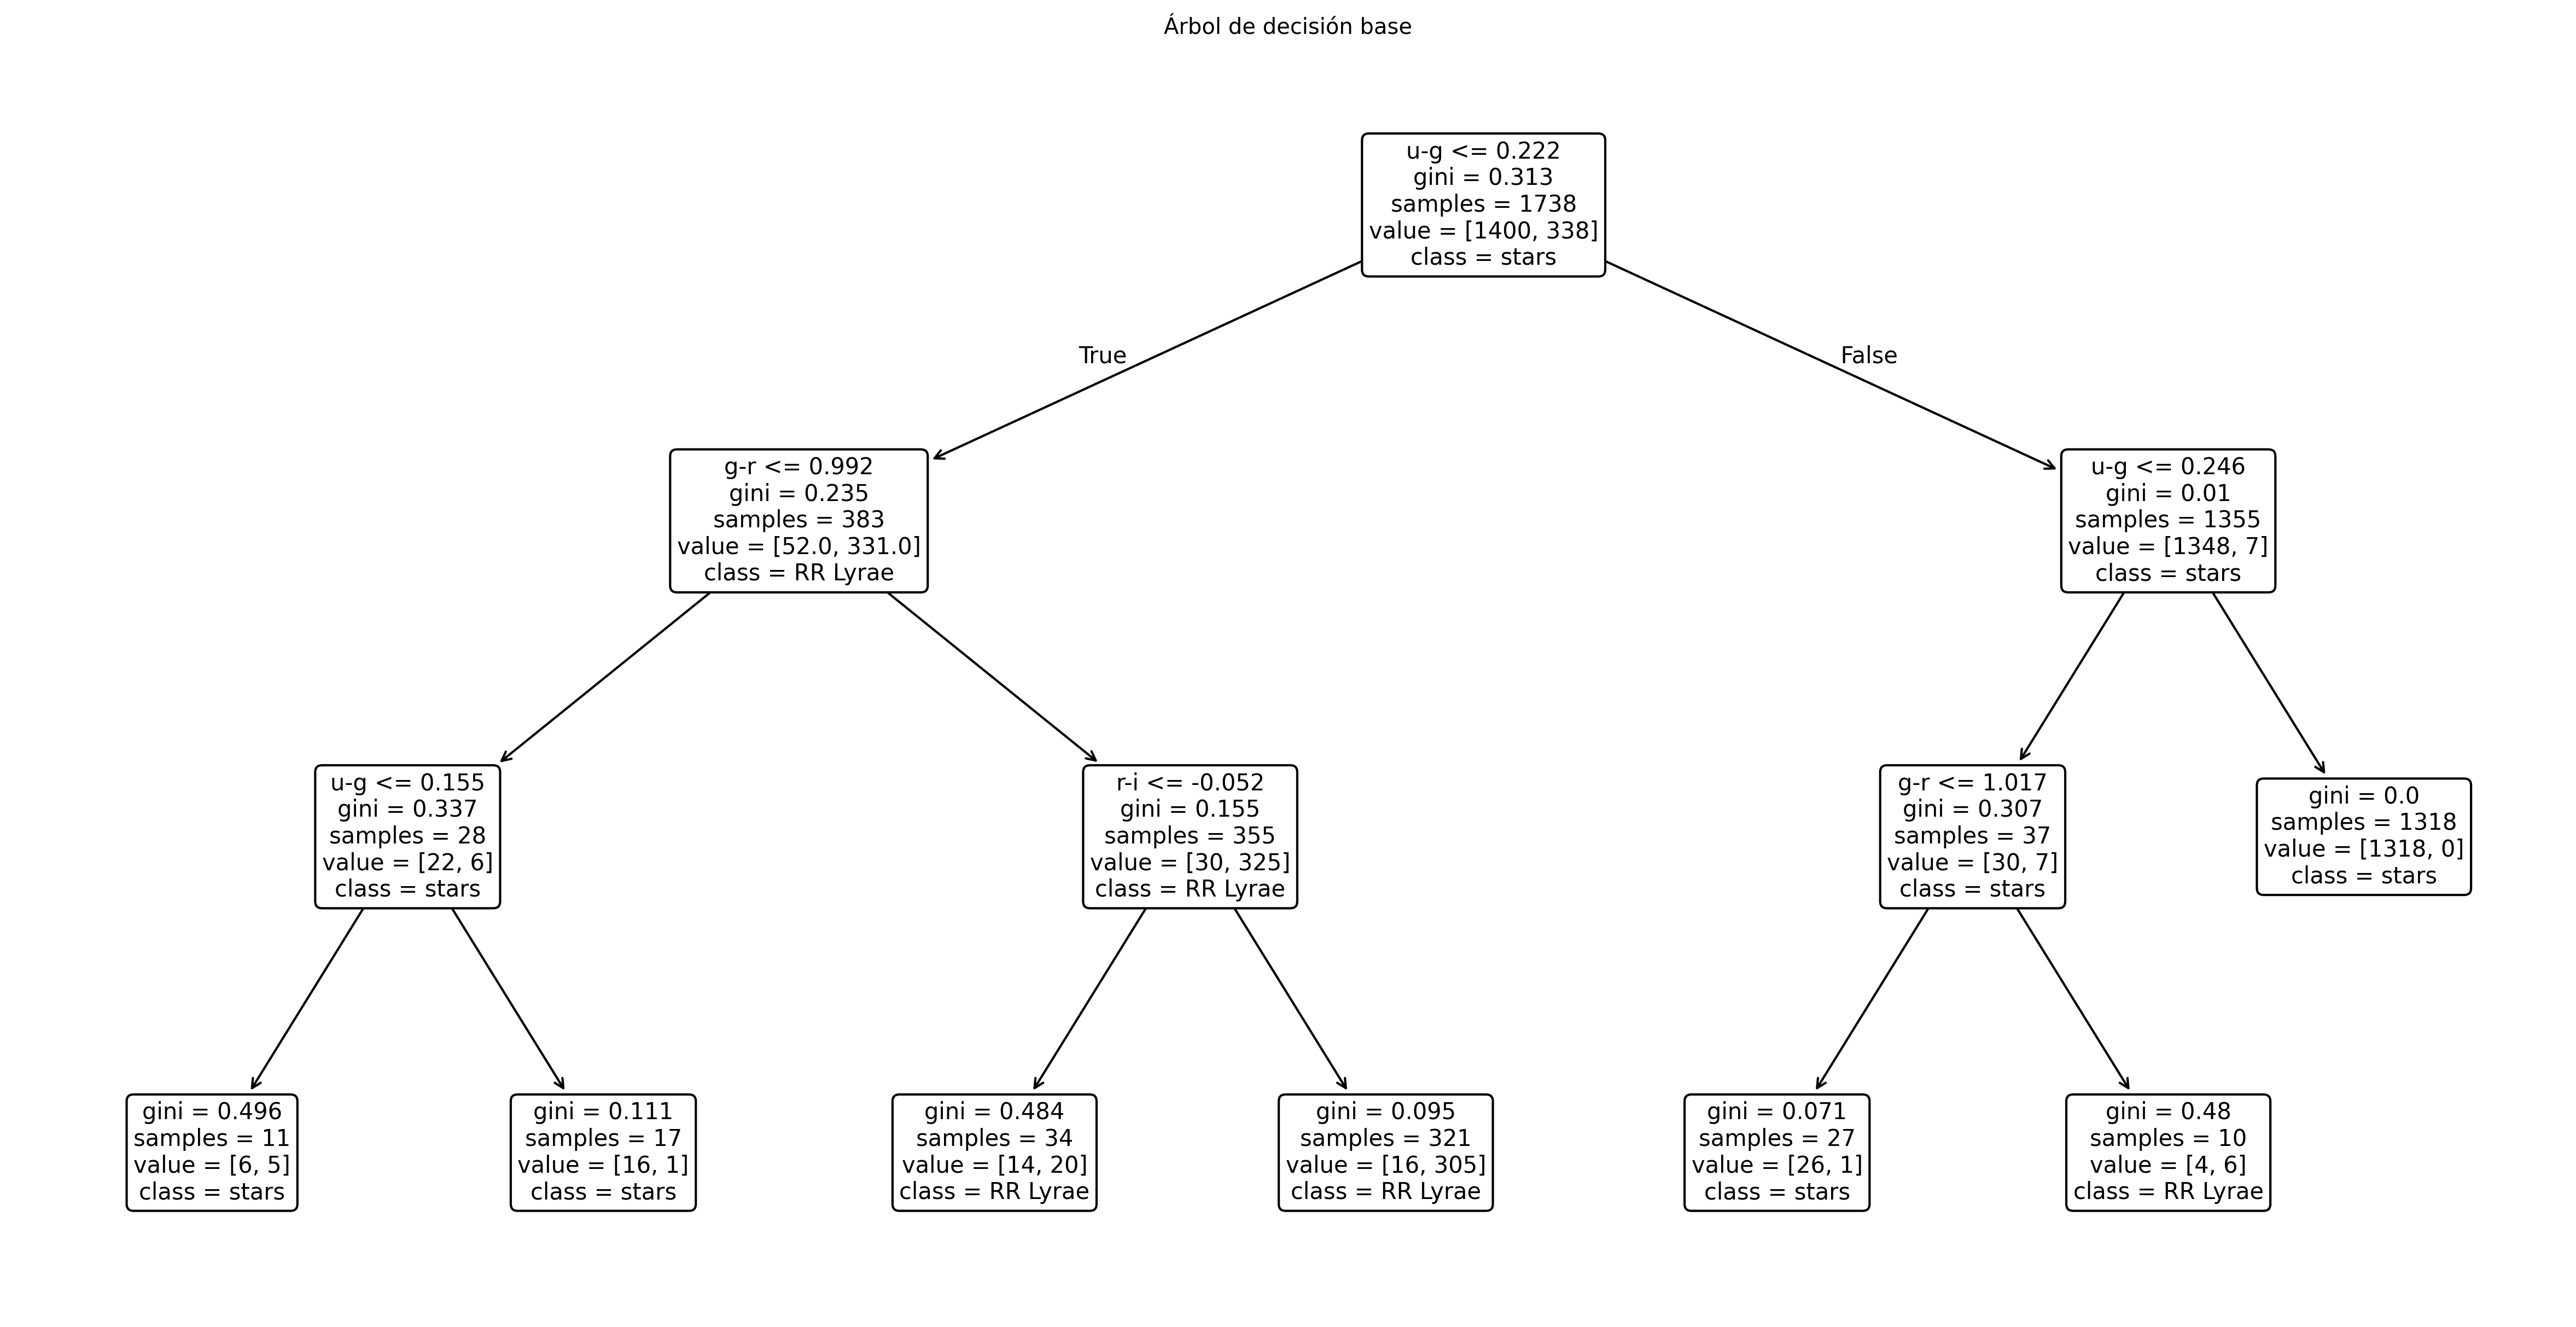

In [45]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree2,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

Accuracy:  0.974
Precision: 0.922
Recall:    0.946
F1-score:  0.934


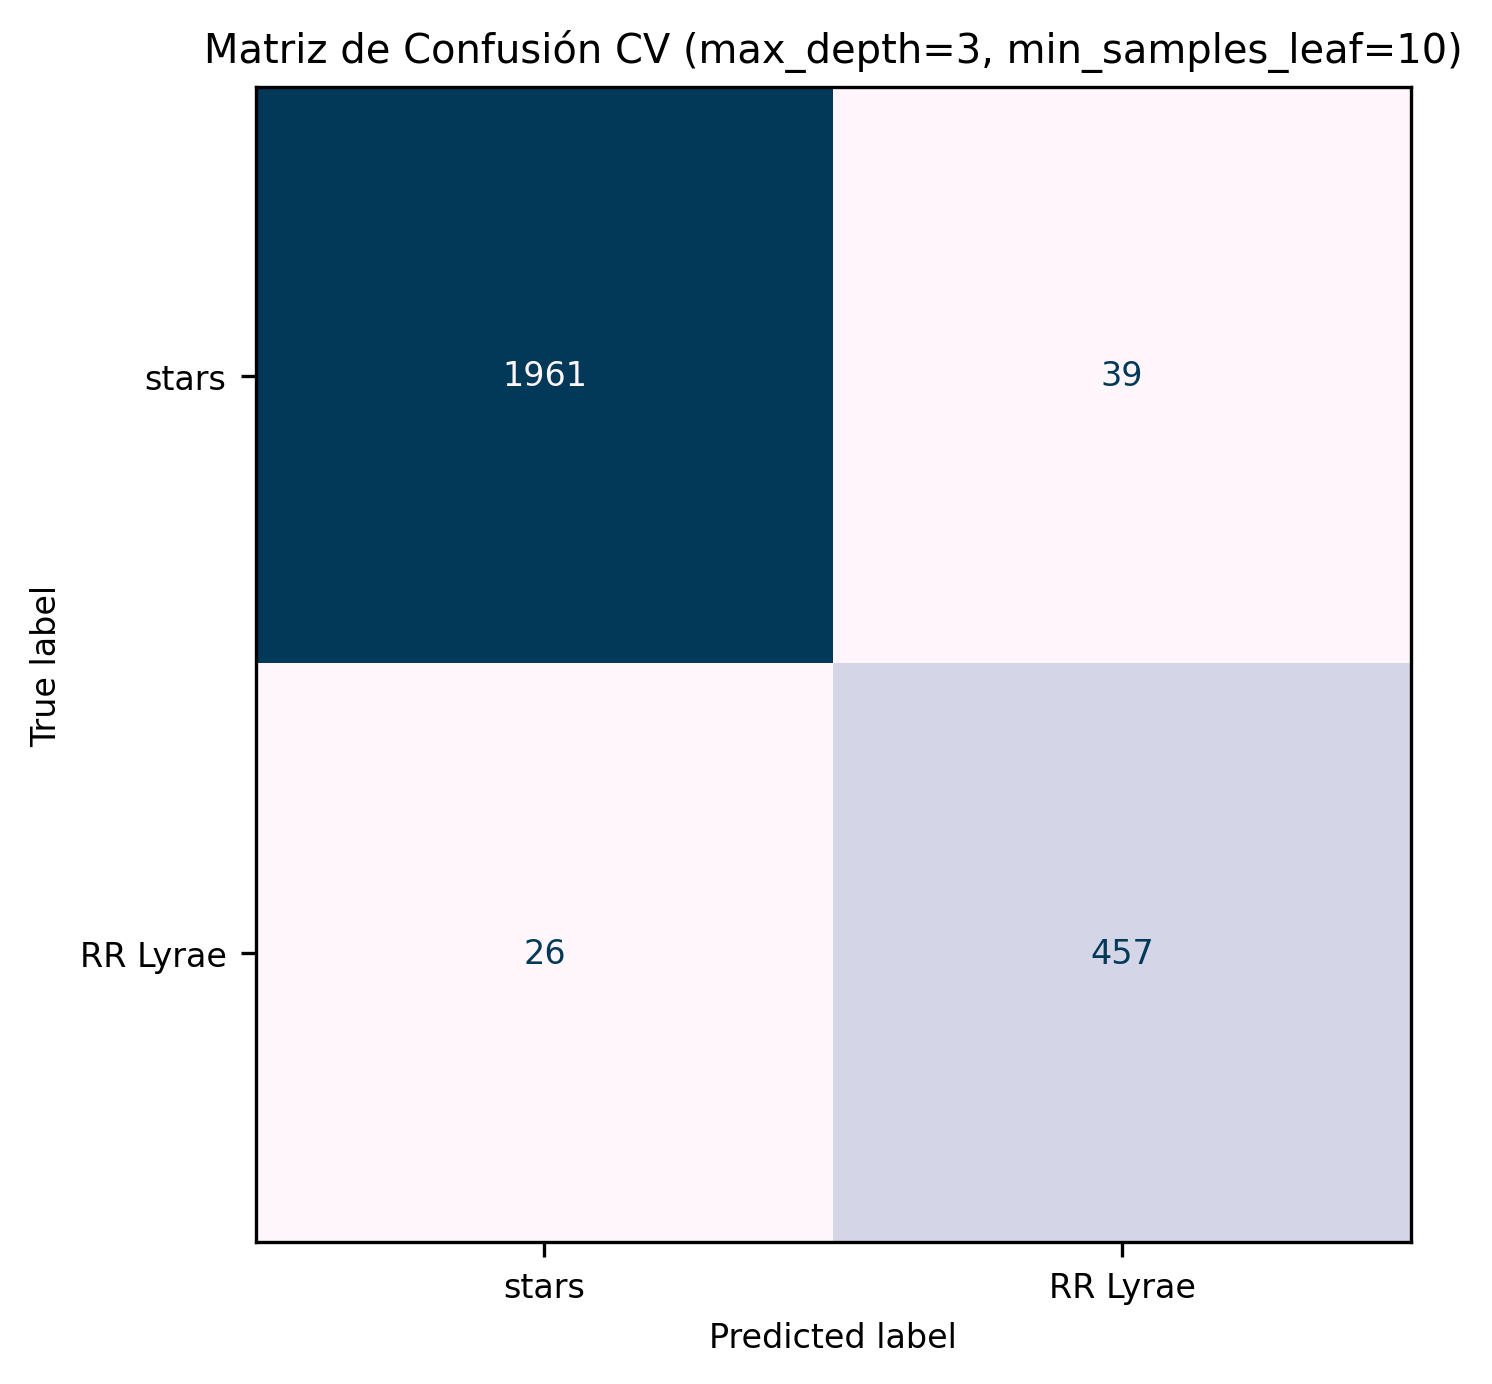

In [46]:
#aplicamos la cross validation
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']
scores_hp = cross_validate(model_tree2, X, y, cv=cv3, scoring=scoring_metrics)

print(f"Accuracy:  {scores_hp['test_accuracy'].mean():.3f}")
print(f"Precision: {scores_hp['test_precision'].mean():.3f}")
print(f"Recall:    {scores_hp['test_recall'].mean():.3f}")
print(f"F1-score:  {scores_hp['test_f1'].mean():.3f}")

y_pred_cv3 = cross_val_predict(model_tree2, X, y, cv=cv3) #hago las predicciones


cm3= confusion_matrix(y, y_pred_cv3)
fig,ax = plt.subplots(figsize=(5,5))
disp3=ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=["stars", "RR Lyrae"])
disp3.plot(cmap="PuBu", ax=ax, colorbar=False)
plt.title("Matriz de Confusión CV (max_depth=3, min_samples_leaf=10)")
plt.show()

### Preguntas

A partir de los resultados obtenidos con validación cruzada:

1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?
2. ¿El árbol más simple empeoró o mejoró la generalización?
3. ¿Qué sugieren estos resultados sobre el árbol base?
4. En este problema, ¿parece conveniente usar el árbol sin restricciones?
5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?

#### RESPUESTAS:
1. El rendimiento es mas estable, el arbol sin restricciones termina simplemente apredendiendo el set, mientras que este mas simple no.
2. Mejoro la generalizacion
3. que el primer arbol sin restricciones estaba sobreajustando
4. No, es mejor el arbol con restricciones, sobretodo porque tenemos datos desbalanceados
5. El recall y el f1-score

## Desafío: comparar con kNN

Hasta ahora trabajamos con árboles de decisión. Ahora comparemos ese enfoque con un clasificador distinto: **k-Nearest Neighbors (kNN)**.

Entrene un modelo kNN y compárelo con el árbol simple usando validación cruzada estratificada. Recuerde que kNN está basado en distancias, por lo que antes de entrenarlo debe escalar las variables.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando:
   - accuracy
   - precision
   - recall
   - F1-score
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.

### Preguntas

1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?
2. ¿Qué ocurre cuando `k` es muy pequeño?
3. ¿Qué ocurre cuando `k` es muy grande?
4. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall?
5. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?

#### Respuestas: 
1. en general es mejor, ofrece un rednimiento mas equilibrado en recall y f1
2. el modelo se vueñve muy sensible a datos atipicos
3. si es muy grande el modelo con los datos desbalanceados sufrira de subajuste
4. k=3 parece mas equilibrado
5. Knn es mas flexible en ese aspecto, puede trazar fronteras aunque sean irregulares, cosa que no el arbol de dicision no puede


Accuracy:0.978
Precision:0.922
Recall:0.969
F1-score: 0.945


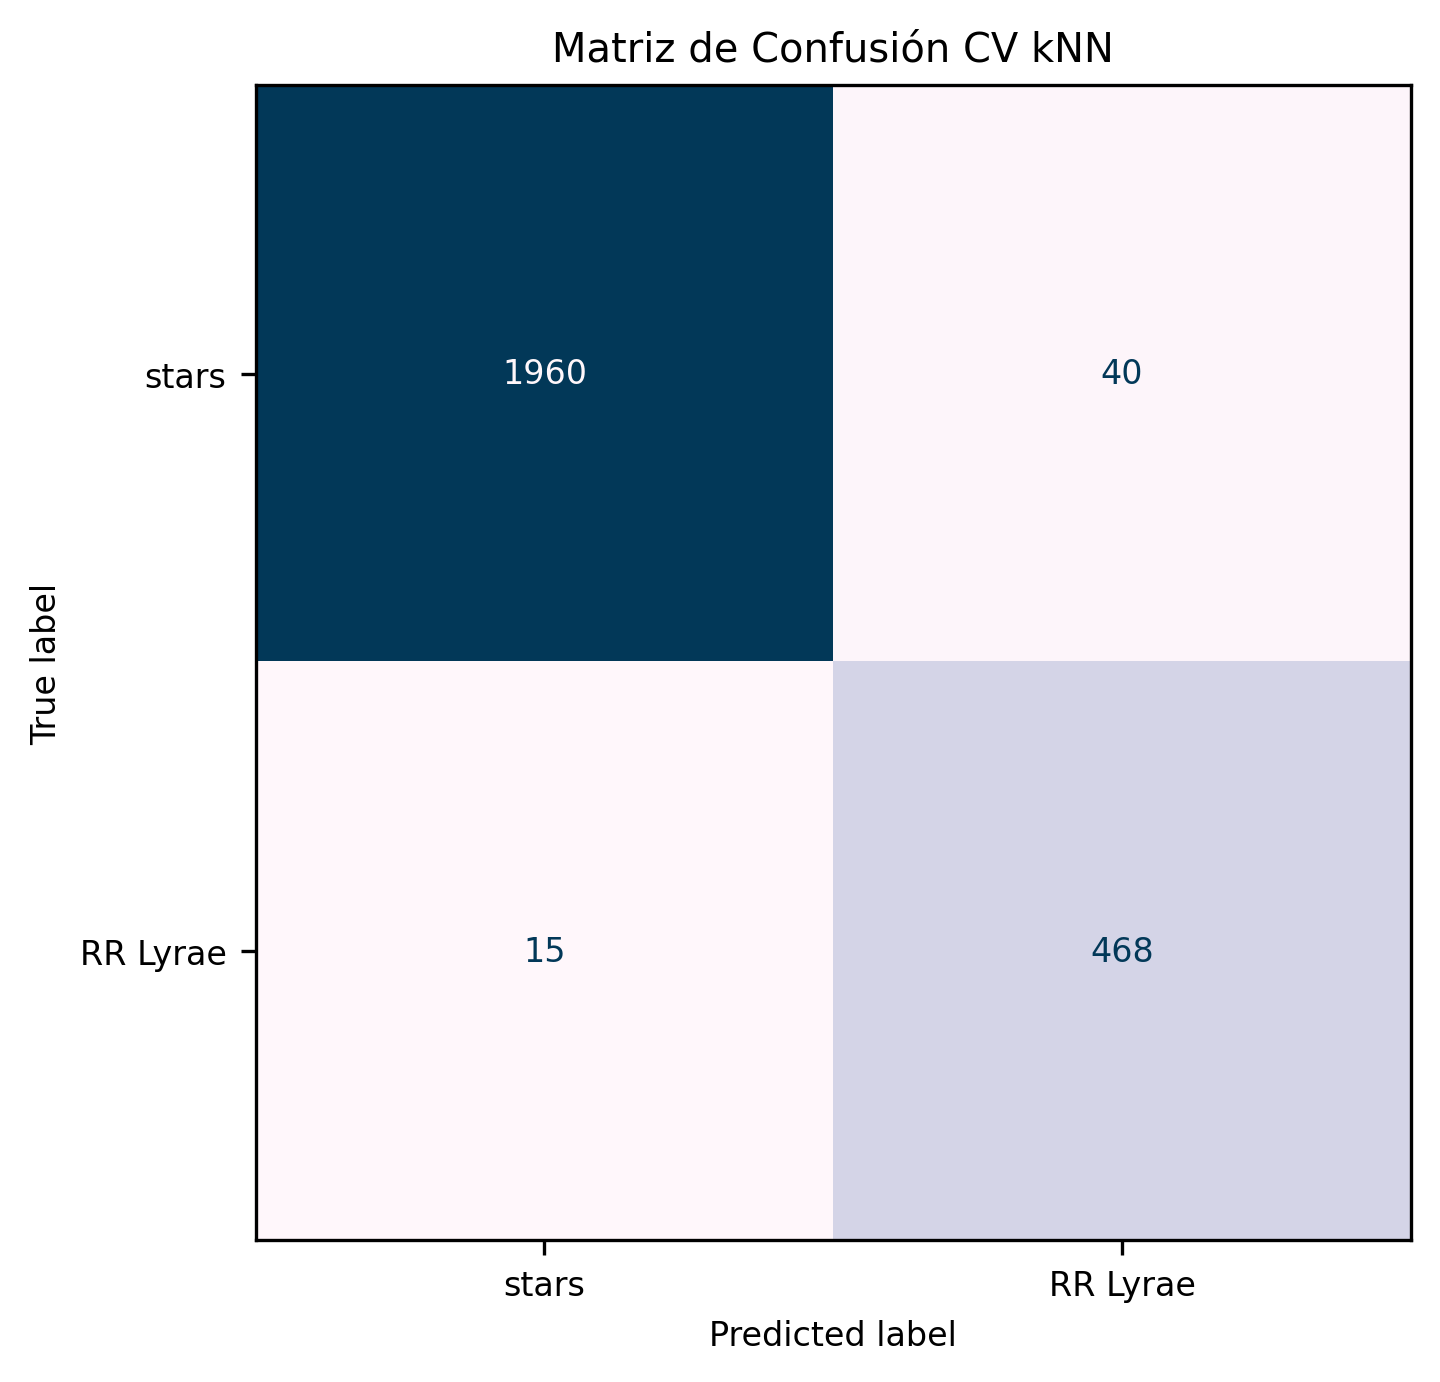

In [47]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

knn_modelo = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)) #creo el modelo y escalo los datos

scores_knn = cross_validate(knn_modelo, X, y, cv=cv3, scoring=scoring_metrics) #hago la vaalidacion cruzada


print(f"Accuracy:{scores_knn['test_accuracy'].mean():.3f}")
print(f"Precision:{scores_knn['test_precision'].mean():.3f}")
print(f"Recall:{scores_knn['test_recall'].mean():.3f}")
print(f"F1-score: {scores_knn['test_f1'].mean():.3f}")


y_pred_cv_knn = cross_val_predict(knn_modelo, X, y, cv=cv3) #hago las predicciones 
cm_knn = confusion_matrix(y, y_pred_cv_knn) #creo la matriz de confusion



fig,ax=plt.subplots(figsize=(5,5))
disp_knn=ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["stars","RR Lyrae"])
disp_knn.plot(cmap="PuBu", ax=ax, colorbar=False)
plt.title("Matriz de Confusión CV kNN")
plt.show()


In [48]:
#pruebo distintos valores para k 
k_values = [1, 3, 5, 10, 20, 50]
for k in k_values:
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    scores = cross_validate(pipe, X, y, cv=cv3, scoring=['precision', 'recall', 'f1'])
    print(f"k={k:2d} | Precision: {scores['test_precision'].mean():.3f} | Recall: {scores['test_recall'].mean():.3f} | F1-Score: {scores['test_f1'].mean():.3f}")

k= 1 | Precision: 0.914 | Recall: 0.923 | F1-Score: 0.919
k= 3 | Precision: 0.923 | Recall: 0.961 | F1-Score: 0.941
k= 5 | Precision: 0.922 | Recall: 0.969 | F1-Score: 0.945
k=10 | Precision: 0.919 | Recall: 0.977 | F1-Score: 0.947
k=20 | Precision: 0.898 | Recall: 0.973 | F1-Score: 0.934
k=50 | Precision: 0.893 | Recall: 0.973 | F1-Score: 0.931


## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.